# Programming Assignment 4 LUCAS


In [30]:
import pandas as pd

In [31]:
import matplotlib.pyplot as plt

In [5]:
#Load Dataset
df = pd.read_csv("board2.csv")

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Dataset loaded successfully.
Number of rows: 30
Number of columns: 8


,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88


Average Column

In [6]:
df_with_average = df.copy()

df_with_average["Average"] = df_with_average[
    ["Math", "GEAS", "Electronics", "Communication"]
].mean(axis=1)

print("Dataset with Average column:")
display(df_with_average)

Dataset with Average column:


,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


A. VISAYAS COMMUNICATION DATAFRAME

In [9]:
print("A. VISAYAS COMMUNICATION DATAFRAME")

# Students must satisfy BOTH conditions:
# 1. Hometown is Visayas
# 2. Track is Communication

VisComm = df_with_average.loc[
    (df_with_average["Hometown"] == "Visayas") &
    (df_with_average["Track"] == "Communication"),
    ["Name", "Gender", "Math", "Electronics", "Average"]
]

print("\nVisComm:")
display(VisComm)

print("Number of rows in VisComm:", len(VisComm))

A. VISAYAS COMMUNICATION DATAFRAME

VisComm:


,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


Number of rows in VisComm: 5


B. VISAYAS FEMALE DATAFRAME

In [10]:
print("B. VISAYAS FEMALE DATAFRAME")


# Students must satisfy BOTH conditions:
# 1. Hometown is Visayas
# 2. Gender is Female

VisFemale = df_with_average.loc[
    (df_with_average["Hometown"] == "Visayas") &
    (df_with_average["Gender"] == "Female"),
    ["Name", "Track", "GEAS", "Electronics", "Average"]
]

print("\nVisFemale:")
display(VisFemale)

B. VISAYAS FEMALE DATAFRAME

VisFemale:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


B.1 Average >= 60

In [12]:
print("VisFemale students with Average >= 60:")

VisFemale_60 = VisFemale.loc[
    VisFemale["Average"] >= 60
]

display(VisFemale_60)

VisFemale students with Average >= 60:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


C. CATEGORY-AVERAGE VISUALIZATION

C.a MEAN AVERAGE BY TRACK, GENDER, AND HOMETOWN

In [15]:
track_mean = (
    df_with_average
    .groupby("Track")["Average"]
    .mean()
    .reset_index()
)

track_mean = track_mean.rename(
    columns={"Average": "Mean Average"}
)

print("Mean Average by Track:")
display(track_mean)

gender_mean = (
    df_with_average
    .groupby("Gender")["Average"]
    .mean()
    .reset_index()
)

gender_mean = gender_mean.rename(
    columns={"Average": "Mean Average"}
)

print("\nMean Average by Gender:")
display(gender_mean)

hometown_mean = (
    df_with_average
    .groupby("Hometown")["Average"]
    .mean()
    .reset_index()
)

hometown_mean = hometown_mean.rename(
    columns={"Average": "Mean Average"}
)

print("\nMean Average by Hometown:")
display(hometown_mean)

Mean Average by Track:


,Track,Mean Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500



Mean Average by Gender:


,Gender,Mean Average
0,Female,66.616667
1,Male,67.183333



Mean Average by Hometown:


,Hometown,Mean Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


 C.b DISPLAY THREE SUMMARY TABLES

In [16]:
print("SUMMARY TABLES")


print("\n1. Mean Average by Track")
display(track_mean)

print("\n2. Mean Average by Gender")
display(gender_mean)

print("\n3. Mean Average by Hometown")
display(hometown_mean)

SUMMARY TABLES

1. Mean Average by Track


,Track,Mean Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500



2. Mean Average by Gender


,Gender,Mean Average
0,Female,66.616667
1,Male,67.183333



3. Mean Average by Hometown


,Hometown,Mean Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


C.c CREATE ONE FIGURE WITH THREE BAR CHARTS

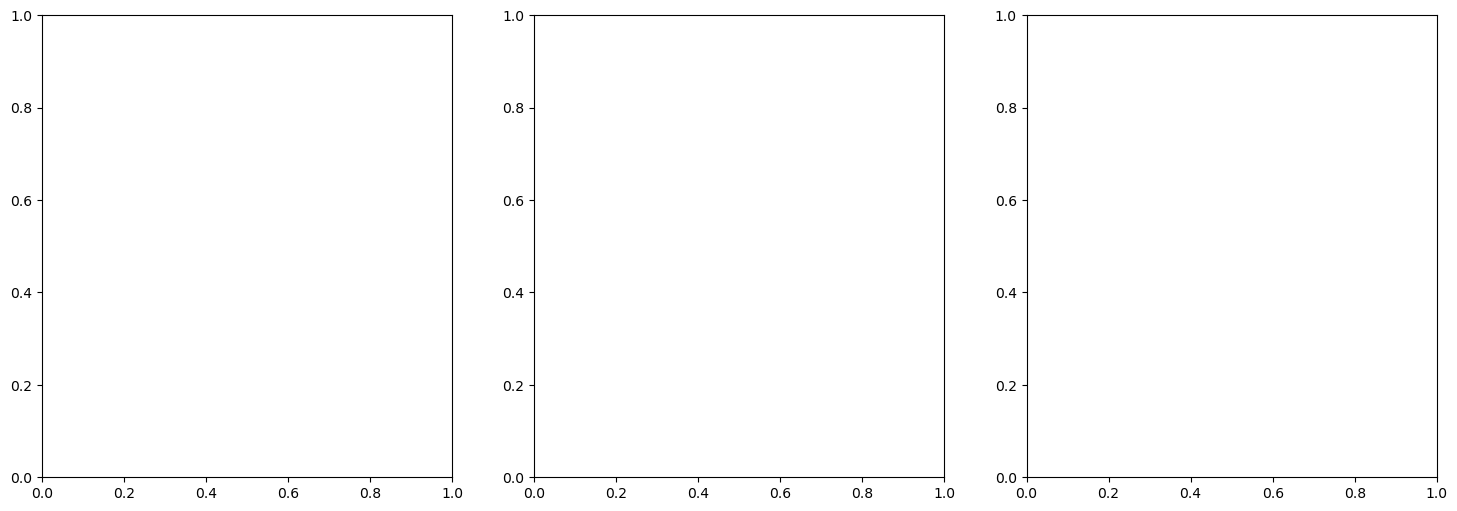

In [17]:
# Find the largest mean value so all three graphs
# can use the same y-axis scale.

maximum_mean = max(
    track_mean["Mean Average"].max(),
    gender_mean["Mean Average"].max(),
    hometown_mean["Mean Average"].max()
)

y_limit = maximum_mean * 1.10


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)


BAR CHARTS: TRACK

In [34]:
axes[0].bar(
    track_mean["Track"],
    track_mean["Mean Average"]
)

axes[0].set_title("Mean Average by Track")
axes[0].set_xlabel("Track")
axes[0].set_ylabel("Mean Average")
axes[0].set_ylim(0, y_limit)

axes[0].tick_params(
    axis="x",
    rotation=45
)

BAR CHART 2: GENDER

In [22]:
axes[1].bar(
    gender_mean["Gender"],
    gender_mean["Mean Average"]
)

axes[1].set_title("Mean Average by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Mean Average")
axes[1].set_ylim(0, y_limit)

axes[1].tick_params(
    axis="x",
    rotation=45
)


BAR CHART 3: HOMETOWN

In [35]:
axes[2].bar(
    hometown_mean["Hometown"],
    hometown_mean["Mean Average"]
)

axes[2].set_title("Mean Average by Hometown")
axes[2].set_xlabel("Hometown")
axes[2].set_ylabel("Mean Average")
axes[2].set_ylim(0, y_limit)

axes[2].tick_params(
    axis="x",
    rotation=45
)


# Prevent overlapping labels
plt.tight_layout()

# Display the figure
plt.show()


<Figure size 640x480 with 0 Axes>

C.d THREE INTERPRETATION STATEMENTS

In [36]:
highest_track = track_mean.loc[
    track_mean["Mean Average"].idxmax()
]

highest_gender = gender_mean.loc[
    gender_mean["Mean Average"].idxmax()
]

highest_hometown = hometown_mean.loc[
    hometown_mean["Mean Average"].idxmax()
]


print("INTERPRETATION")


# Statement 1: Track

print(
    f"1. Among the Track categories, "
    f"{highest_track['Track']} has the highest sample mean "
    f"Average of {highest_track['Mean Average']:.2f}."
)


# Statement 2: Gender

print(
    f"2. Among the Gender categories, "
    f"{highest_gender['Gender']} has the highest sample mean "
    f"Average of {highest_gender['Mean Average']:.2f}."
)


# Statement 3: Hometown

print(
    f"3. Among the Hometown categories, "
    f"{highest_hometown['Hometown']} has the highest sample mean "
    f"Average of {highest_hometown['Mean Average']:.2f}."
)


INTERPRETATION
1. Among the Track categories, Communication has the highest sample mean Average of 67.97.
2. Among the Gender categories, Male has the highest sample mean Average of 67.18.
3. Among the Hometown categories, Luzon has the highest sample mean Average of 68.08.


FINAL CHECK

In [37]:
print("FINAL CHECK")

print("VisComm rows:", len(VisComm))
print("VisFemale rows:", len(VisFemale))
print("VisFemale Average >= 60 rows:", len(VisFemale_60))


FINAL CHECK
VisComm rows: 5
VisFemale rows: 6
VisFemale Average >= 60 rows: 4
